# Recording Inventory and Train/Validation Balance

This notebook reads **only CSV filenames**. It does not read IMU samples, require labels, or modify files. Use it before auto-labeling to inspect how recordings are distributed by gesture, participant, and split.

Expected names are `imu_<person>_<gesture>_<YYYYMMDD>_<HHMMSS>.csv` and `imuStrict_<person>_<gesture>_<YYYYMMDD>_<HHMMSS>.csv`. The gesture is everything after the participant name and before the timestamp. For example, `imu_Miguel_knock_twice_left_20260929_142641.csv` is attributed to participant `Miguel` and gesture `knock_twice_left`.

In [1]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# This works when the notebook is started from the repository root or notebooks_analysis/.
working_dir = Path.cwd().resolve()
REPO_ROOT = next((path for path in (working_dir, *working_dir.parents)
                  if (path / 'tap_recognition').is_dir()), None)
assert REPO_ROOT is not None, 'Run this notebook inside the TapRecognition repository.'

# Change this to Path('/data') or another directory when auditing a different dataset.
DATA_DIR = REPO_ROOT / 'data_02_10_26'

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25})
print(f'Repository: {REPO_ROOT}')
print(f'Data directory: {DATA_DIR}')

Repository: /home/aprohack/desktop/work/tap-project/project/tapRecognitionRui/TapRecognition
Data directory: /home/aprohack/desktop/work/tap-project/project/tapRecognitionRui/TapRecognition/data_02_10_26


## Discover and parse recordings

A file under `train_data` is classified as `train`; one under `valid_data` or `validation_data` is classified as `validation`. Files elsewhere remain `unassigned`, which makes it easy to audit an unsplit `/data` directory. Files that do not match the expected filename format are listed separately rather than silently counted incorrectly.

In [2]:
FILENAME_PATTERN = re.compile(
    r'^(?P<collection>imu(?:Strict)?)_(?P<person>[^_]+)_'
    r'(?P<gesture>.+)_(?P<timestamp>\d{8}_\d{6})\.csv$',
    re.IGNORECASE,
)
SPLIT_BY_DIRECTORY = {
    'train_data': 'train',
    'valid_data': 'validation',
    'validation_data': 'validation',
}

def split_from_path(path: Path) -> str:
    for part in path.parts:
        split = SPLIT_BY_DIRECTORY.get(part.lower())
        if split is not None:
            return split
    return 'unassigned'


csv_paths = sorted(
    path for path in DATA_DIR.rglob('*.csv')
    if not path.name.endswith('.labels.csv')
)
rows = []
unparsed = []
for path in csv_paths:
    match = FILENAME_PATTERN.fullmatch(path.name)
    relative_path = str(path.relative_to(DATA_DIR))
    if match is None:
        unparsed.append(relative_path)
        continue
    fields = match.groupdict()
    rows.append({
        'path': relative_path,
        'collection': fields['collection'],
        'person': fields['person'],
        'gesture': fields['gesture'],
        'timestamp': pd.to_datetime(fields['timestamp'], format='%Y%m%d_%H%M%S'),
        'split': split_from_path(path),
    })

records = pd.DataFrame(rows, columns=['path', 'collection', 'person', 'gesture', 'timestamp', 'split'])
if records.empty:
    raise RuntimeError(f'No recording filenames matching the expected format were found under {DATA_DIR}.')
records = records.sort_values(['split', 'person', 'gesture', 'timestamp']).reset_index(drop=True)

print(f'CSV files found: {len(csv_paths)}')
print(f'Recordings parsed: {len(records)}')
print(f'Filename(s) not parsed: {len(unparsed)}')
display(records.head(10))
if unparsed:
    display(pd.DataFrame({'unparsed_csv': unparsed}))

CSV files found: 133
Recordings parsed: 132
Filename(s) not parsed: 1


,path,collection,person,gesture,timestamp,split
0,train_data/imu_Miguel_adjust_grip_20260921_172...,imu,Miguel,adjust_grip,2026-09-21 17:27:17,train
1,train_data/imu_Miguel_adjust_grip_20260923_175...,imu,Miguel,adjust_grip,2026-09-23 17:58:13,train
2,train_data/imu_Miguel_adjust_grip_20260929_141...,imu,Miguel,adjust_grip,2026-09-29 14:19:22,train
3,train_data/imu_Miguel_adjust_grip_20260929_142...,imu,Miguel,adjust_grip,2026-09-29 14:20:34,train
4,train_data/imu_Miguel_arbitrary_20260921_17241...,imu,Miguel,arbitrary,2026-09-21 17:24:16,train
5,train_data/imu_Miguel_arbitrary_20260924_09360...,imu,Miguel,arbitrary,2026-09-24 09:36:02,train
6,train_data/imu_Miguel_knock_once_20260924_0934...,imu,Miguel,knock_once,2026-09-24 09:34:28,train
7,train_data/imu_Miguel_knock_once_20260925_1024...,imu,Miguel,knock_once,2026-09-25 10:24:44,train
8,train_data/imu_Miguel_knock_once_20260929_1415...,imu,Miguel,knock_once,2026-09-29 14:15:25,train
9,train_data/imu_Miguel_knock_twice_left_2026092...,imu,Miguel,knock_twice_left,2026-09-21 17:16:41,train


,unparsed_csv
0,session_exclusions.csv


## Inventory by gesture and participant

,recordings,gestures,people,strict recordings,unassigned recordings
0,132,8,7,49,0


Recordings per gesture


,recordings,people,first_recording,last_recording,share_of_all_recordings_pct
gesture,,,,,
knock_twice_right,43,6,2026-09-04 09:51:27,2026-10-02 11:02:26,32.6
knock_twice_left,42,6,2026-09-04 09:50:15,2026-10-02 11:03:33,31.8
shake_phone,19,3,2026-09-04 10:28:26,2026-10-02 11:08:31,14.4
pick_place,8,2,2026-09-09 09:13:35,2026-09-30 15:25:25,6.1
knock_once,7,2,2026-09-21 17:21:28,2026-09-30 15:24:02,5.3
adjust_grip,5,1,2026-09-21 17:27:17,2026-09-29 14:20:34,3.8
switch_hand,5,2,2026-09-09 09:28:38,2026-09-30 14:59:12,3.8
arbitrary,3,1,2026-09-21 17:23:05,2026-09-24 09:36:02,2.3


Recordings per participant


,recordings,gestures,first_recording,last_recording
person,,,,
Miguel,115,8,2026-09-21 17:16:41,2026-10-02 11:08:31
ZR,5,3,2026-09-04 10:28:26,2026-09-09 09:28:38
OLV,4,4,2026-09-23 17:43:50,2026-09-23 17:49:32
JYH,2,2,2026-09-16 14:28:14,2026-09-16 14:29:27
YYQ,2,2,2026-09-04 09:57:40,2026-09-04 09:58:56
Ym,2,2,2026-09-04 11:09:25,2026-09-04 11:10:43
yzj,2,2,2026-09-04 09:50:15,2026-09-04 09:51:27


Recording count by participant and gesture


gesture,adjust_grip,arbitrary,knock_once,knock_twice_left,knock_twice_right,pick_place,shake_phone,switch_hand
person,,,,,,,,
JYH,0,0,0,1,1,0,0,0
Miguel,5,3,6,37,38,7,15,4
OLV,0,0,1,1,1,0,1,0
YYQ,0,0,0,1,1,0,0,0
Ym,0,0,0,1,1,0,0,0
ZR,0,0,0,0,0,1,3,1
yzj,0,0,0,1,1,0,0,0


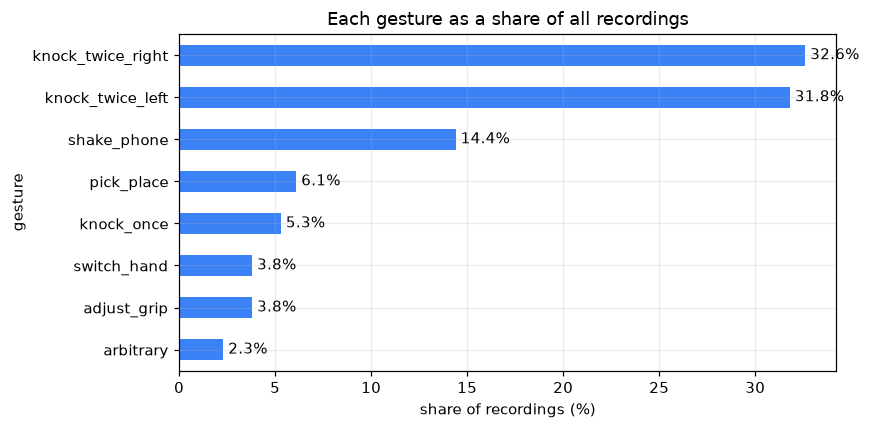

In [3]:
overview = pd.DataFrame({
    'recordings': [len(records)],
    'gestures': [records['gesture'].nunique()],
    'people': [records['person'].nunique()],
    'strict recordings': [(records['collection'].str.lower() == 'imustrict').sum()],
    'unassigned recordings': [(records['split'] == 'unassigned').sum()],
})
display(overview)

gesture_inventory = (
    records.groupby('gesture')
    .agg(recordings=('path', 'size'), people=('person', 'nunique'),
         first_recording=('timestamp', 'min'), last_recording=('timestamp', 'max'))
    .sort_values(['recordings', 'gesture'], ascending=[False, True])
)
gesture_inventory['share_of_all_recordings_pct'] = (
    100 * gesture_inventory['recordings'] / len(records)
).round(1)
person_inventory = (
    records.groupby('person')
    .agg(recordings=('path', 'size'), gestures=('gesture', 'nunique'),
         first_recording=('timestamp', 'min'), last_recording=('timestamp', 'max'))
    .sort_values(['recordings', 'person'], ascending=[False, True])
)

print('Recordings per gesture')
display(gesture_inventory)

ax = gesture_inventory['share_of_all_recordings_pct'].sort_values().plot.barh(
    figsize=(8, max(3, len(gesture_inventory) * 0.5)), color='#3B82F6'
)
ax.set_title('Each gesture as a share of all recordings')
ax.set_xlabel('share of recordings (%)')
ax.set_ylabel('gesture')
for bar in ax.patches:
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
            f' {bar.get_width():.1f}%', va='center')
plt.tight_layout()
print('Recordings per participant')
display(person_inventory)
print('Recording count by participant and gesture')
display(pd.crosstab(records['person'], records['gesture']))

## Train/validation balance

The validation percentage is compared with the overall validation percentage among assigned recordings. A large positive or negative `delta_vs_overall_pp` means that gesture or participant is over-represented in validation or training. `unassigned` recordings are shown but excluded from that percentage.

In [4]:
SPLIT_ORDER = ['train', 'validation', 'unassigned']
assigned = records[records['split'].isin(['train', 'validation'])]
overall_validation_pct = (
    100 * (assigned['split'] == 'validation').mean() if len(assigned) else np.nan
)
print(f'Overall validation share among assigned recordings: {overall_validation_pct:.1f}%')

def balance_table(column: str) -> pd.DataFrame:
    table = pd.crosstab(records[column], records['split']).reindex(columns=SPLIT_ORDER, fill_value=0)
    assigned_total = table['train'] + table['validation']
    table['total'] = assigned_total + table['unassigned']
    table['validation_pct'] = (100 * table['validation'] / assigned_total.replace(0, np.nan)).round(1)
    table['delta_vs_overall_pp'] = (table['validation_pct'] - overall_validation_pct).round(1)
    return table.sort_values('total', ascending=False, kind='stable')

gesture_balance = balance_table('gesture')
person_balance = balance_table('person')
print('Balance by gesture')
display(gesture_balance)
print('Balance by participant')
display(person_balance)

Overall validation share among assigned recordings: 33.3%
Balance by gesture


split,train,validation,unassigned,total,validation_pct,delta_vs_overall_pp
gesture,,,,,,
knock_twice_right,29,14,0,43,32.6,-0.7
knock_twice_left,29,13,0,42,31.0,-2.3
shake_phone,12,7,0,19,36.8,3.5
pick_place,6,2,0,8,25.0,-8.3
knock_once,4,3,0,7,42.9,9.6
adjust_grip,4,1,0,5,20.0,-13.3
switch_hand,2,3,0,5,60.0,26.7
arbitrary,2,1,0,3,33.3,-0.0


Balance by participant


split,train,validation,unassigned,total,validation_pct,delta_vs_overall_pp
person,,,,,,
Miguel,78,37,0,115,32.2,-1.1
ZR,0,5,0,5,100.0,66.7
OLV,4,0,0,4,0.0,-33.3
JYH,0,2,0,2,100.0,66.7
YYQ,2,0,0,2,0.0,-33.3
Ym,2,0,0,2,0.0,-33.3
yzj,2,0,0,2,0.0,-33.3


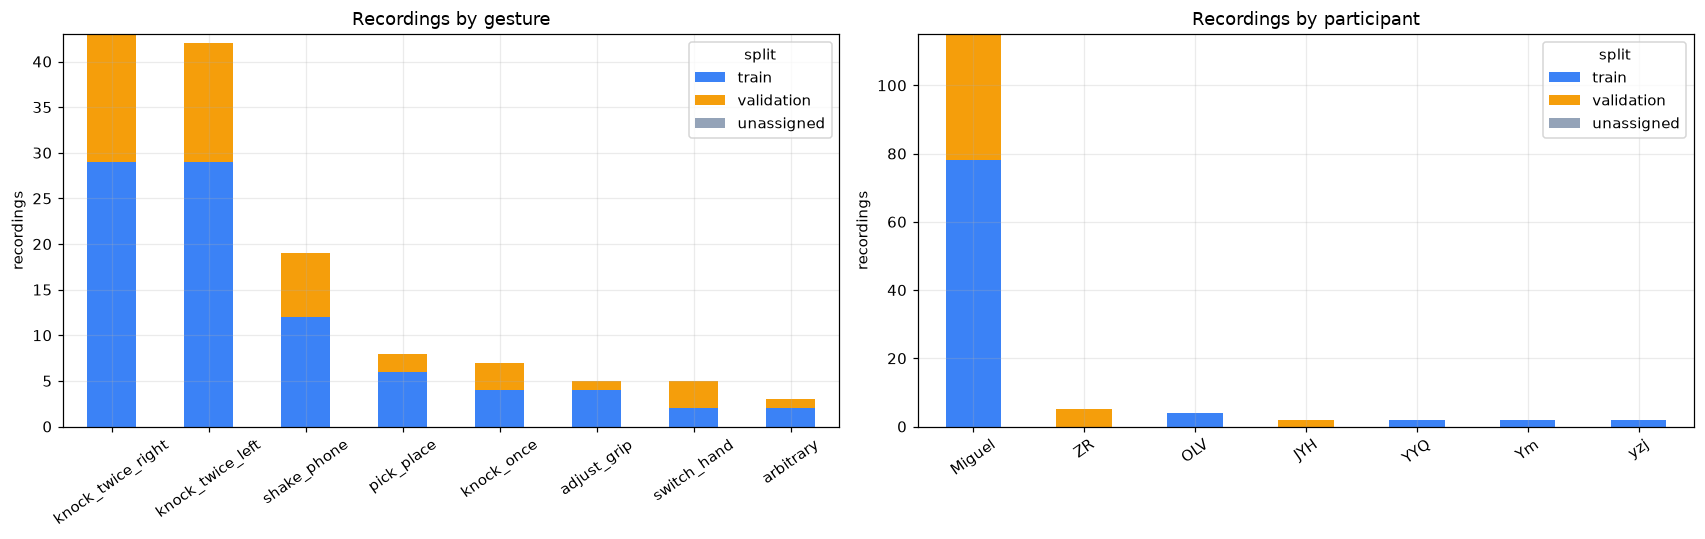

In [5]:
def plot_split_counts(table: pd.DataFrame, title: str, ax: plt.Axes) -> None:
    table[SPLIT_ORDER].plot(
        kind='bar', stacked=True, ax=ax,
        color={'train': '#3B82F6', 'validation': '#F59E0B', 'unassigned': '#94A3B8'},
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('recordings')
    ax.tick_params(axis='x', rotation=35)
    ax.legend(title='split')

fig, axes = plt.subplots(1, 2, figsize=(max(14, len(gesture_balance) * 1.25 + len(person_balance) * 0.8), 5))
plot_split_counts(gesture_balance, 'Recordings by gesture', axes[0])
plot_split_counts(person_balance, 'Recordings by participant', axes[1])
fig.tight_layout()

## Participant-by-gesture coverage

This table shows the detailed split counts. The heatmap shows the percentage of assigned recordings in validation for every participant/gesture combination; `-` means that combination has no assigned recording.

split,person,gesture,train,validation,unassigned,total,validation_pct
6,Miguel,knock_twice_right,25,13,0,38,34.2
5,Miguel,knock_twice_left,25,12,0,37,32.4
8,Miguel,shake_phone,11,4,0,15,26.7
7,Miguel,pick_place,6,1,0,7,14.3
4,Miguel,knock_once,3,3,0,6,50.0
2,Miguel,adjust_grip,4,1,0,5,20.0
9,Miguel,switch_hand,2,2,0,4,50.0
3,Miguel,arbitrary,2,1,0,3,33.3
19,ZR,shake_phone,0,3,0,3,100.0
0,JYH,knock_twice_left,0,1,0,1,100.0


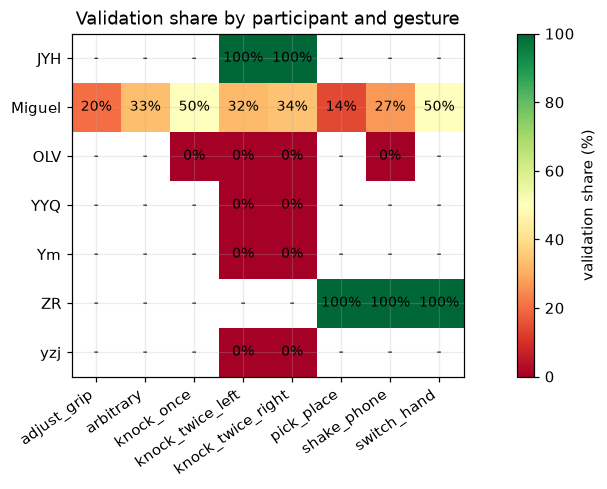

In [6]:
pair_counts = pd.crosstab([records['person'], records['gesture']], records['split'])
pair_counts = pair_counts.reindex(columns=SPLIT_ORDER, fill_value=0)
pair_counts['total'] = pair_counts.sum(axis=1)
pair_counts['validation_pct'] = (
    100 * pair_counts['validation'] / (pair_counts['train'] + pair_counts['validation']).replace(0, np.nan)
).round(1)
display(pair_counts.reset_index().sort_values(['total', 'person', 'gesture'], ascending=[False, True, True]))

train_matrix = pd.crosstab(records['person'], records['gesture'],
                           values=(records['split'] == 'train'), aggfunc='sum').fillna(0)
validation_matrix = pd.crosstab(records['person'], records['gesture'],
                                values=(records['split'] == 'validation'), aggfunc='sum').fillna(0)
validation_matrix = validation_matrix.reindex(index=train_matrix.index, columns=train_matrix.columns, fill_value=0)
validation_share = 100 * validation_matrix / (train_matrix + validation_matrix).replace(0, np.nan)

fig, ax = plt.subplots(figsize=(max(8, len(validation_share.columns) * 1.25),
                               max(3, len(validation_share.index) * 0.65)))
image = ax.imshow(validation_share.to_numpy(dtype=float), vmin=0, vmax=100, cmap='RdYlGn')
ax.set_xticks(range(len(validation_share.columns)), validation_share.columns, rotation=35, ha='right')
ax.set_yticks(range(len(validation_share.index)), validation_share.index)
ax.set_title('Validation share by participant and gesture')
for row_index, person in enumerate(validation_share.index):
    for column_index, gesture in enumerate(validation_share.columns):
        value = validation_share.loc[person, gesture]
        ax.text(column_index, row_index, '-' if pd.isna(value) else f'{value:.0f}%',
                ha='center', va='center', fontsize=9)
fig.colorbar(image, ax=ax, label='validation share (%)')
fig.tight_layout()